In [95]:
import numpy as np
from importlib import reload
import simulate_data as sim
reload(sim)
from gwas import gwas_linear, gwas_probit
from scipy.stats import norm
from tqdm import tqdm

n, d = 1_000, 200
k = 10
corr = 0.7
rho = 0.9
snr_s = 1
snr_y = 2
pi_s = 0.1
pi_y = 0.05
p_sel = 0.3
rng = np.random.default_rng(42)

# LD matrix
#R = sim.simulate_block_ar_correlation_matrix(d, k, rng = rng)
R = sim.simulate_block_correlation_matrix(d, k, corr)


# LD score: l_j = sum_k R_jk^2
ld_score = np.sum(R**2, axis=1)

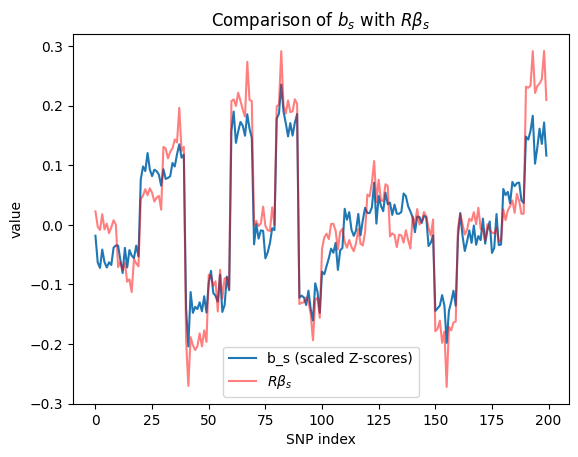

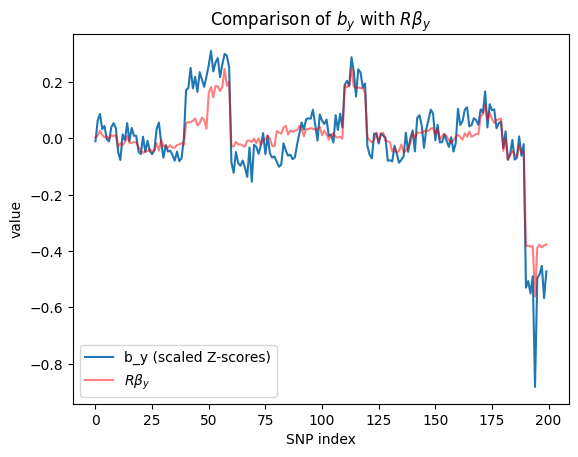

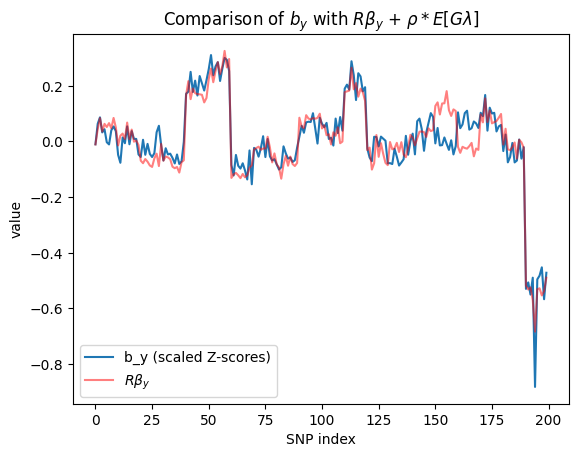

In [96]:
X = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)

beta_s, sigma2_s = sim.beta_heckman(d, R, pi_s, snr_s, rng)
beta_y, sigma2_y = sim.beta_heckman(d, R, pi_y, snr_s, rng)

s, y, s_star, y_star =  sim.heckman_outcome(X, beta_s, beta_y, sigma2_s, sigma2_y, p_sel, rho, rng = rng)

b_s = gwas_probit(X, s)[0] / np.sqrt(len(s))
b_y = gwas_linear(X, y)[0] / np.sqrt(s.sum())


import matplotlib.pyplot as plt
from scipy.stats import norm

def inverse_mills_ratio(eta):
    log_lambda = norm.logpdf(eta) - norm.logcdf(eta)
    return np.exp(log_lambda)

eta = X @ beta_s
lam_eta = inverse_mills_ratio(eta)                  # shape (n,)
E_G_lambda = (X * lam_eta[:, None]).mean(axis=0)    # shape (d,)


R_hat = np.corrcoef(X, rowvar=False)
plt.plot(b_s, label="b_s (scaled Z-scores)")
plt.plot(R_hat @ beta_s , color="red", alpha=0.5, label=r"$R \beta_s$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_s$ with $R\beta_s$")
plt.show()


plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R_hat @ beta_y, color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$")
plt.show()

plt.plot(b_y, label="b_y (scaled Z-scores)")
plt.plot(R_hat @ beta_y + rho*E_G_lambda , color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$ + $\rho*E[G \lambda]$")
plt.show()

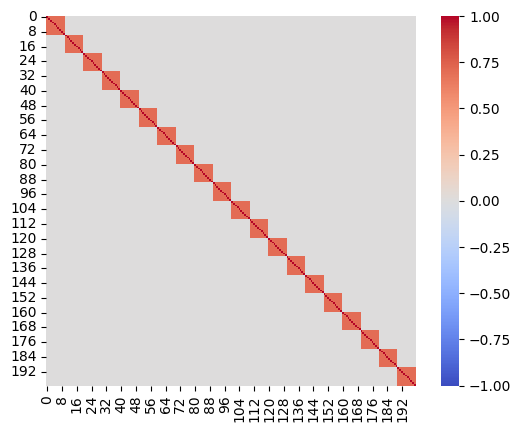

In [112]:
ax = sns.heatmap(
    R,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    square=True
)


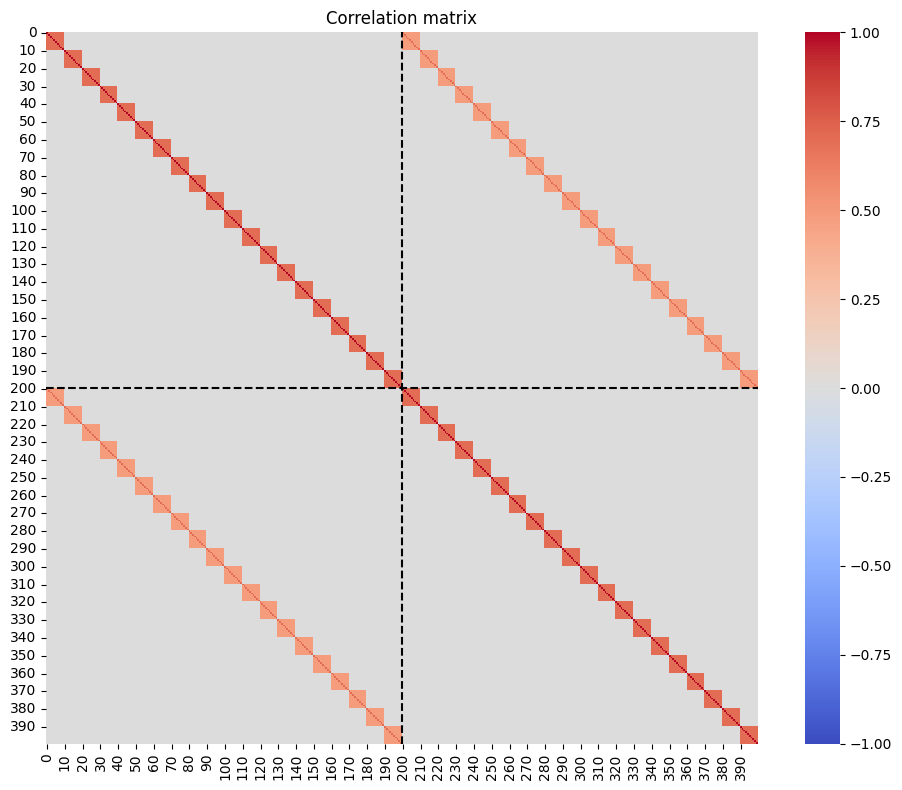

In [110]:
N_s = len(s)
N_y = s.sum()
rho_e = 0.7

def compute_C_kron_R(N_s, N_y, R, rho_e):
    C = np.array([
        [1 / N_s, rho_e / np.sqrt(N_s * N_y)],
        [rho_e / np.sqrt(N_s * N_y), 1 / N_y]
    ])

    C_kron_R = np.kron(C, R)

    return C, C_kron_R

C, C_kron_R = compute_C_kron_R(N_s, N_y, R, rho_e)

corr_C_kron_R = C_kron_R / np.sqrt(np.outer(np.diag(C_kron_R), np.diag(C_kron_R)))
    
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    corr_C_kron_R,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    square=True
)

d = corr_C_kron_R.shape[0] // 2

# Linie dzielące macierz na 4 kwadraty
ax.axhline(d, color="black", linestyle="--", linewidth=1.5)
ax.axvline(d, color="black", linestyle="--", linewidth=1.5)
"""
# Cieńsze, przerywane przekątne każdego z 4 bloków
ax.plot([0, d], [0, d],
        color="black", linestyle="--", linewidth=0.5)

ax.plot([d, 2*d], [0, d],
        color="black", linestyle="--", linewidth=0.5)

ax.plot([0, d], [d, 2*d],
        color="black", linestyle="--", linewidth=0.5)

ax.plot([d, 2*d], [d, 2*d],
        color="black", linestyle="--", linewidth=0.5)
"""
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [ ]:
n_iters = 500

b_s = np.empty((n_iters, d))
b_y = np.empty((n_iters, d))

ZZ = []
N_y_all = []
rho_e0_hats = []
rho_e_hats = []


for i in tqdm(range(n_iters), desc="Simulation iterations"):

    rng = np.random.default_rng(i)
    
    X = sim.simulate_design_matrix(n, R, intercept = False, rng = rng)
    
    beta_s, sigma2_s = sim.beta_heckman(d, R, pi_s, snr_s, rng)
    beta_y, sigma2_y = sim.beta_heckman(d, R, pi_y, snr_s, rng)
    
    s, y, s_star, y_star =  sim.heckman_outcome(X, beta_s, beta_y, sigma2_s, sigma2_y, p_sel, rho, rng = rng)

    N_s = len(s)
    N_y = s.sum()
    
    Z_s = gwas_probit(X, s)[0]
    Z_y = gwas_linear(X, y)[0]
    
    b_s[i, :] = Z_s / np.sqrt(N_s)
    b_y[i, :] = Z_y / np.sqrt(N_y)


     # LDSC
    ZZ = Z_s * Z_y

    slope, intercept = np.polyfit(
        ld_score,
        ZZ,
        deg=1
    )

    # intercept = rho_e
    rho_e_hat = intercept

    # observed overlap fraction
    p_sel_hat = N_y / N_s

    # rho_e,0
    rho_e0_hat = rho_e_hat / np.sqrt(p_sel_hat)

    rho_e_hats.append(rho_e_hat)
    rho_e0_hats.append(rho_e0_hat)

In [105]:
rho_e_hats = np.asarray(rho_e_hats)
rho_e0_hats = np.asarray(rho_e0_hats)

print("rho_e:")
print(rho_e_hats[:10])

print("\nrho_e,0:")
print(rho_e0_hats[:10])

print("\nmean rho_e,0:", rho_e0_hats.mean())
print("sd rho_e,0:", rho_e0_hats.std())

rho_e:
[-1.92712246 -1.30637262 -0.62687724 -2.15045967 -0.14926078 -1.60276993
 -1.43570979 -0.7441423  -0.99861586 -0.70200896]

rho_e,0:
[-3.43363427 -2.36160008 -1.16811678 -4.01412002 -0.28057728 -2.97626905
 -2.62561515 -1.32376975 -1.82321477 -1.29912587]

mean rho_e,0: -1.9059306785408772
sd rho_e,0: 1.103285585742986


In [106]:
# stack the two coefficient series into shape (n_iters, 2): columns = [b_s, b_y]
B = np.column_stack([b_s, b_y])

# sample mean vector m, shape (2,)
m_hat = B.mean(axis=0)

# sample covariance matrix S, shape (2, 2)
# rowvar=False because variables are columns here, not rows
S_hat = np.cov(B, rowvar=False)

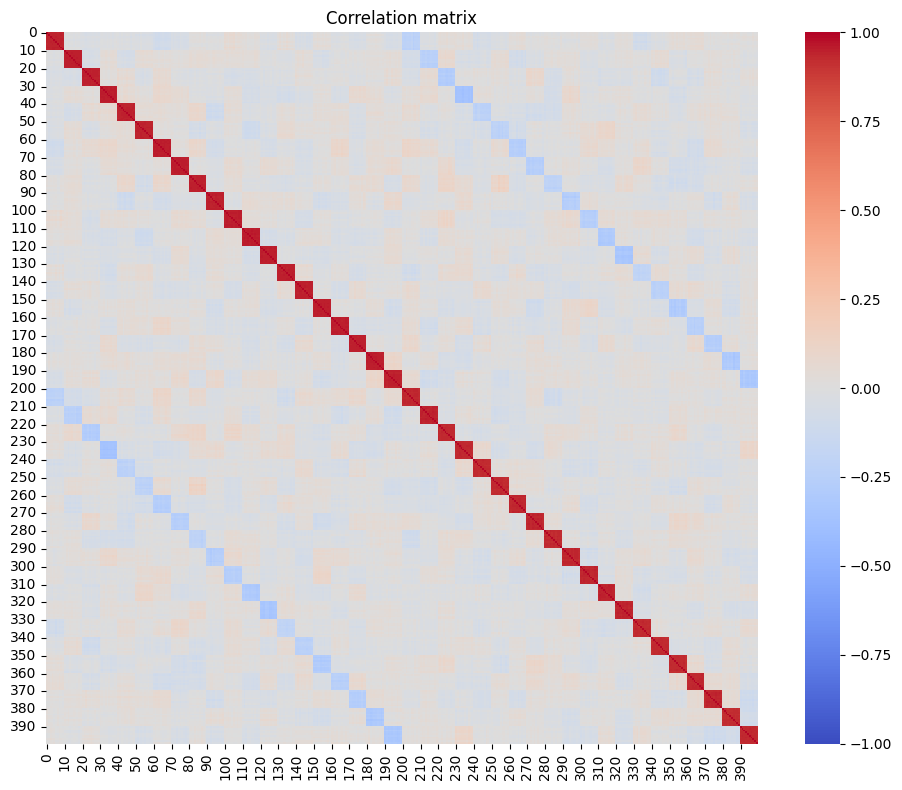

In [107]:
import seaborn as sns

corr = np.corrcoef(B, rowvar=False)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    square=True
)

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

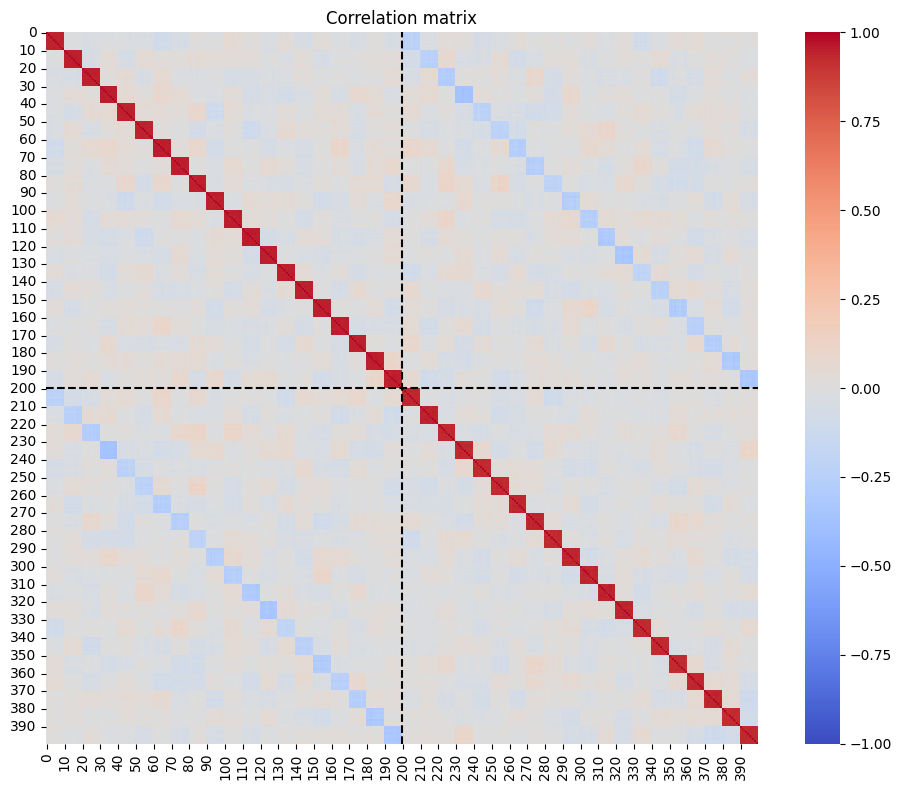

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = np.corrcoef(B, rowvar=False)

d = corr.shape[0] // 2

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    square=True
)

# Linie dzielące macierz na 4 kwadraty
ax.axhline(d, color="black", linestyle="--", linewidth=1.5)
ax.axvline(d, color="black", linestyle="--", linewidth=1.5)
"""
# Przekątne czterech bloków
# lewy górny
ax.plot(
    [0, d],
    [0, d],
    color="black",
    linestyle="--",
    linewidth=0.5
)

# prawy górny
ax.plot(
    [d, 2*d],
    [0, d],
    color="black",
    linestyle="--",
    linewidth=0.5
)

# lewy dolny
ax.plot(
    [0, d],
    [d, 2*d],
    color="black",
    linestyle="--",
    linewidth=0.5
)

# prawy dolny
ax.plot(
    [d, 2*d],
    [d, 2*d],
    color="black",
    linestyle="--",
    linewidth=0.5
)
"""

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

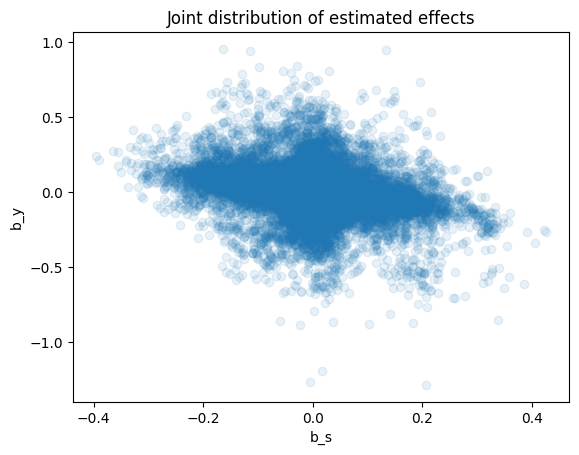

In [103]:
import matplotlib.pyplot as plt

# quick sanity check: scatter of the joint distribution of (b_s, b_y)
plt.scatter(b_s, b_y, alpha=0.1)
plt.xlabel("b_s")
plt.ylabel("b_y")
plt.title("Joint distribution of estimated effects")
plt.show()